In [1]:
!pip -q install holidays japanize-matplotlib xgboost catboost optuna lightgbm

[run] 実行開始...
📁 実験結果出力先: ./experiment_20250608_224451
💻 GPU利用不可: 全モデルでCPU最適化設定を使用

データの読み込み中...
[create_features] 実行開始...
[create_features] 実行完了。所要時間: 0.34 秒
カテゴリカル特徴量をOne-Hotエンコーディングします: ['valencia_weather_main', 'valencia_weather_description', 'valencia_weather_icon', 'madrid_weather_main', 'madrid_weather_description', 'madrid_weather_icon', 'bilbao_weather_main', 'bilbao_weather_description', 'bilbao_weather_icon', 'barcelona_weather_main', 'barcelona_weather_description', 'barcelona_weather_icon', 'seville_weather_main', 'seville_weather_description', 'seville_weather_icon']

使用する特徴量数: 416
訓練データの欠損値数: 0
テストデータの欠損値数: 0

モデル学習・評価フェーズ
[train_and_evaluate] 実行開始...

ベースライン指標: Linear Regression の評価
ベースライン評価は常に全5foldsで実行します（一貫性のため）
  CV開始 (5 folds)
    Fold 1/5: 19.8317 (0.2s)
    Fold 2/5: 10.4263 (0.3s)
    Fold 3/5: 16.4502 (0.3s)
    Fold 4/5: 24.3263 (0.4s)
    Fold 5/5: 8.5224 (0.4s)
  CV結果: 15.9114 ± 5.8507
  -> ベースライン CV Score: 15.9114 (全5 folds使用)
     (この値を上回ることが目標です)

[1/3] li

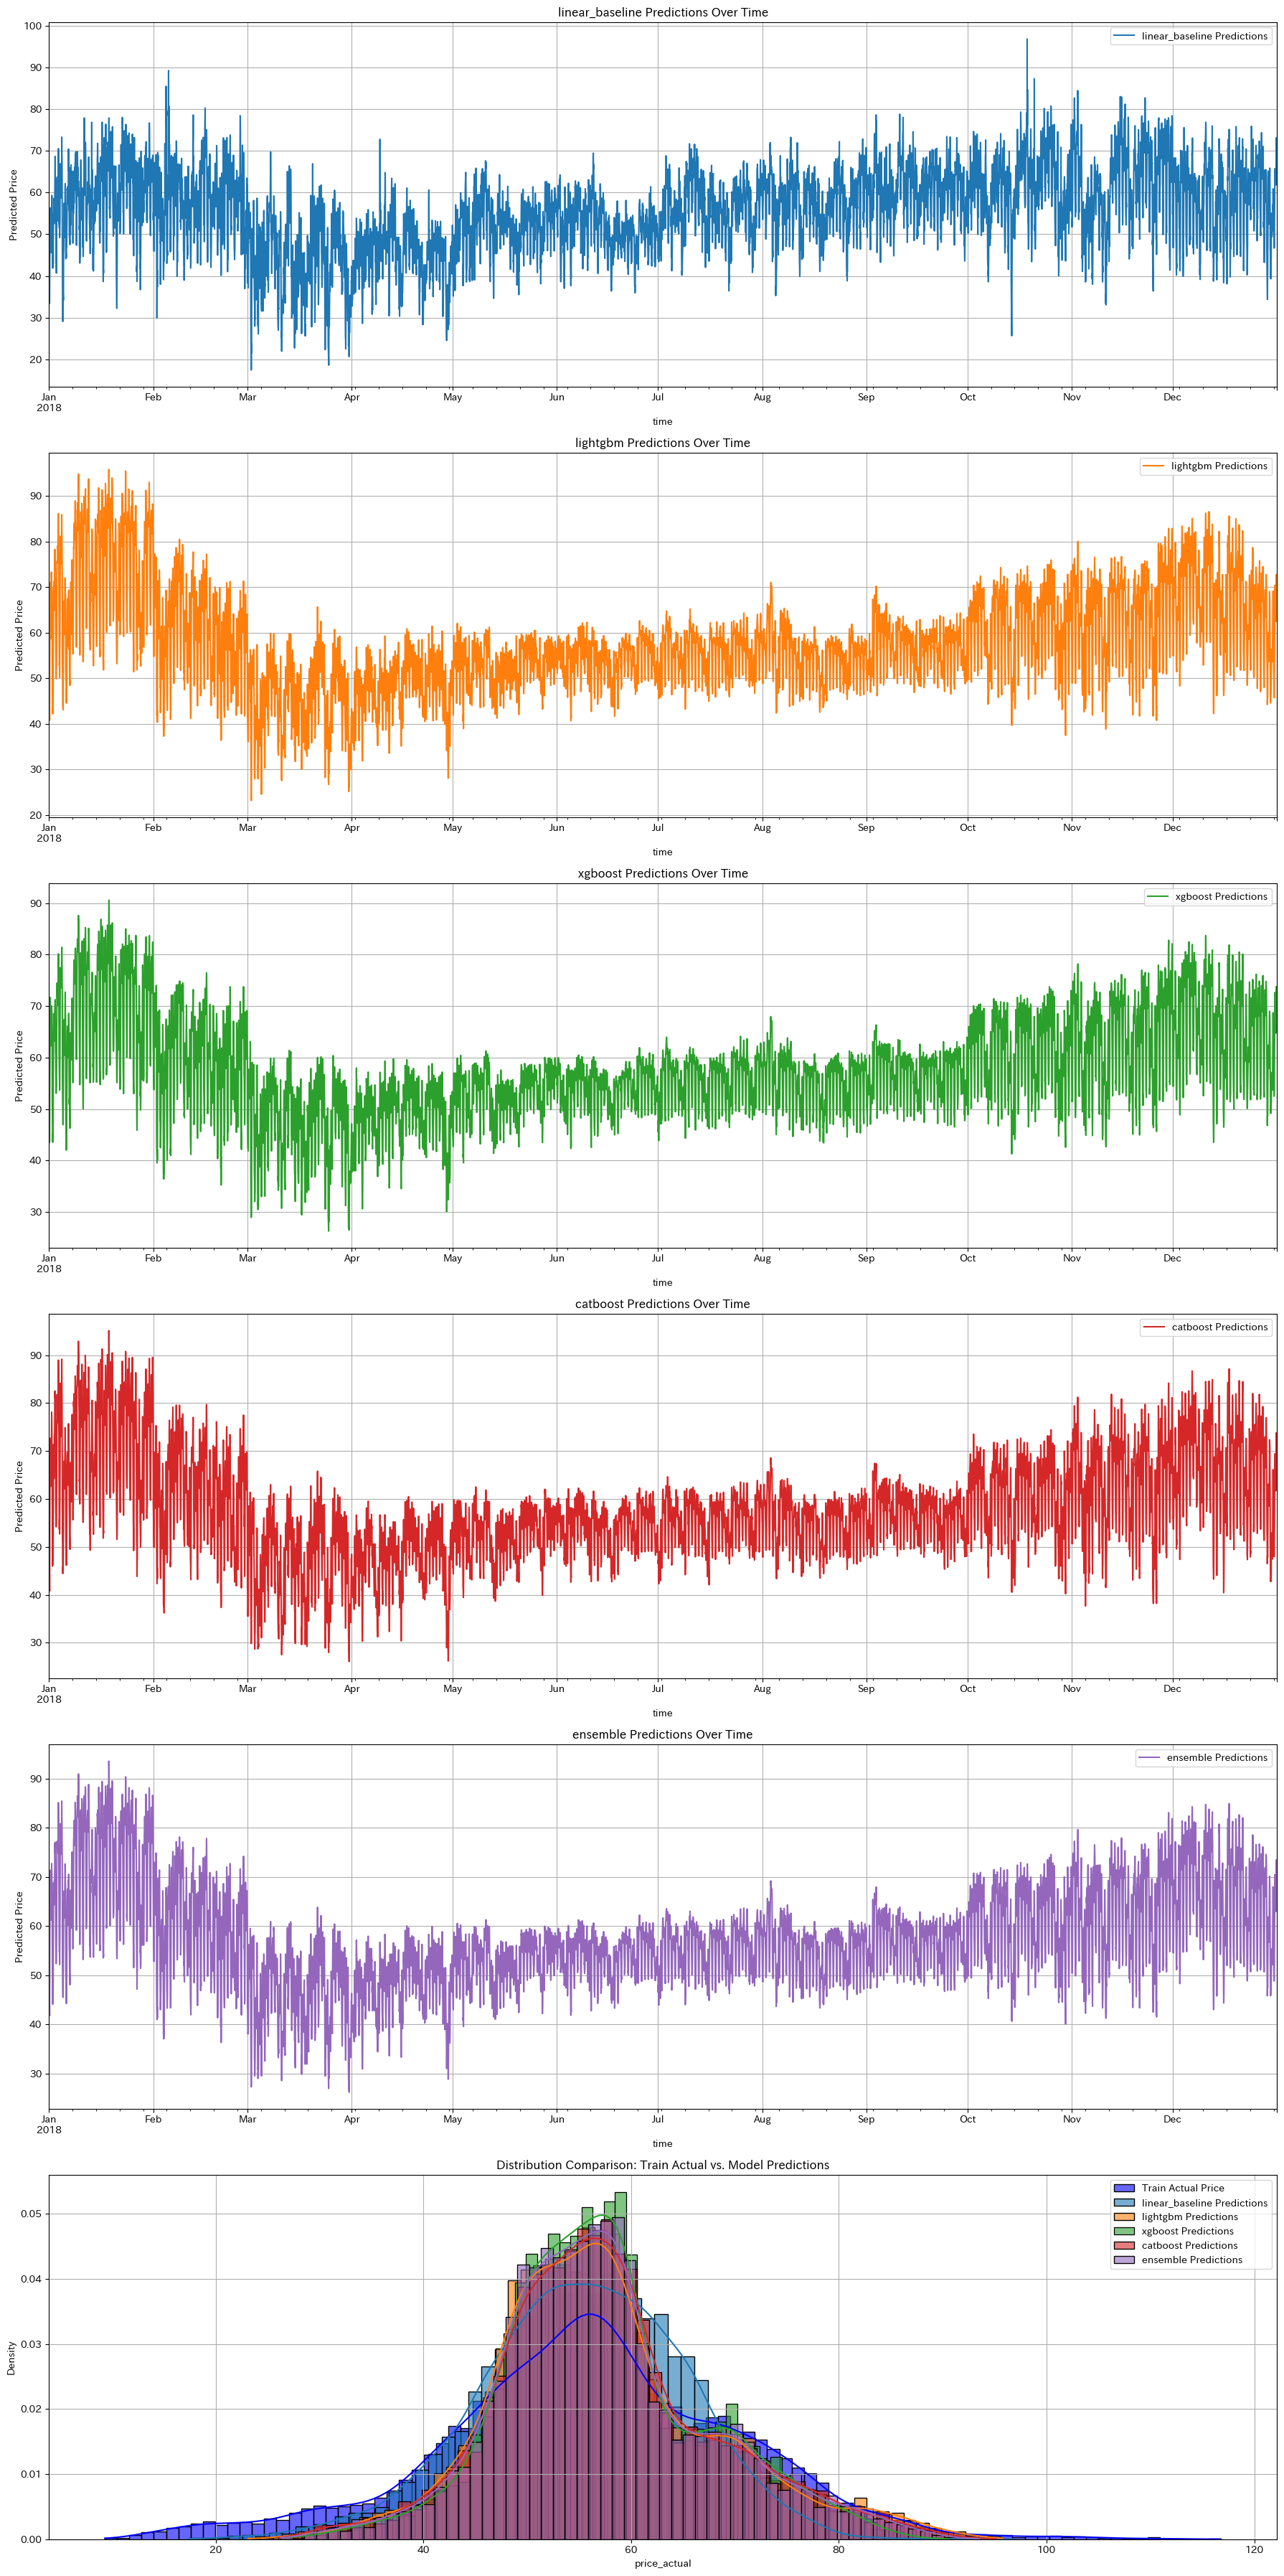

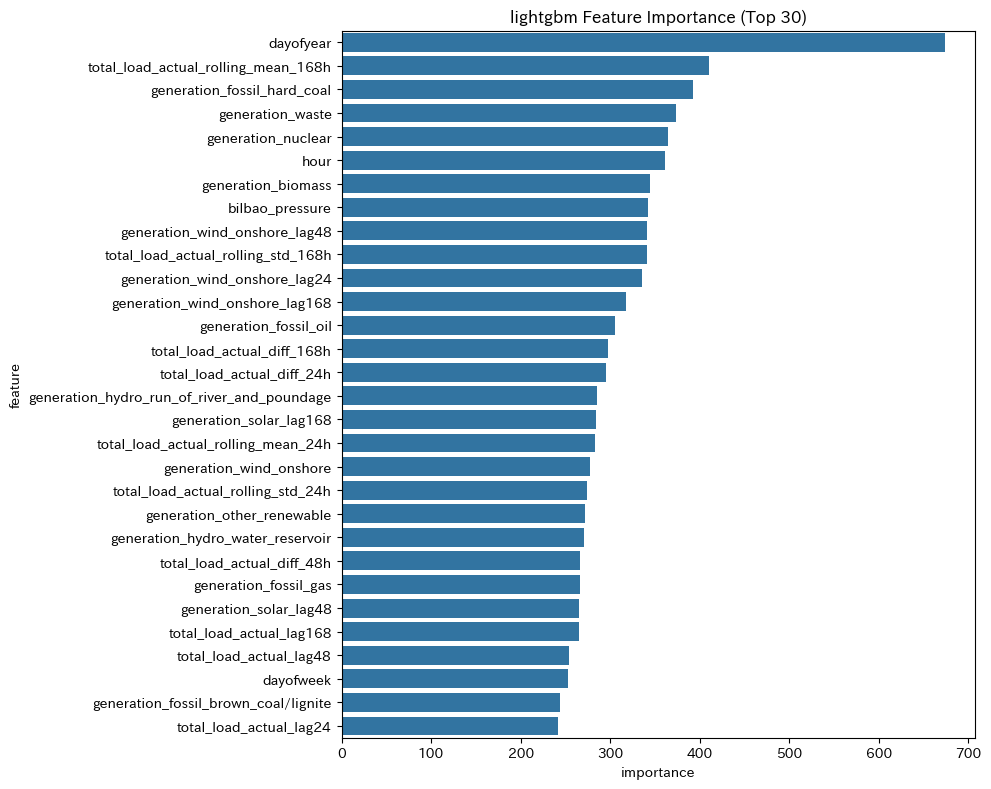

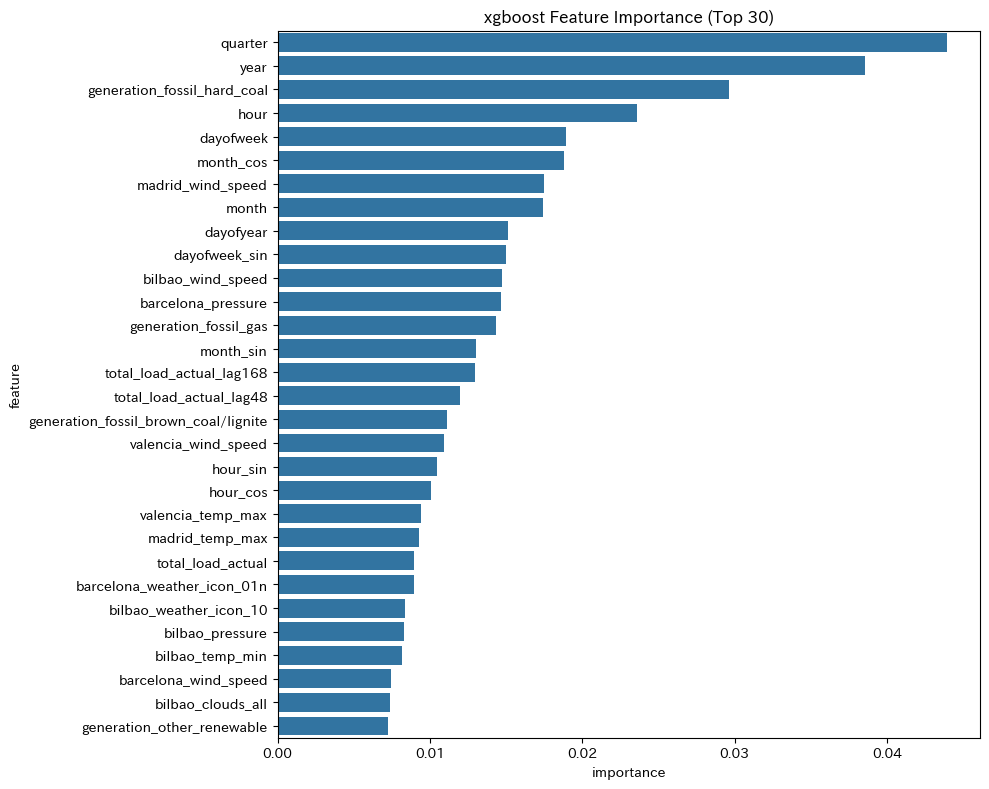

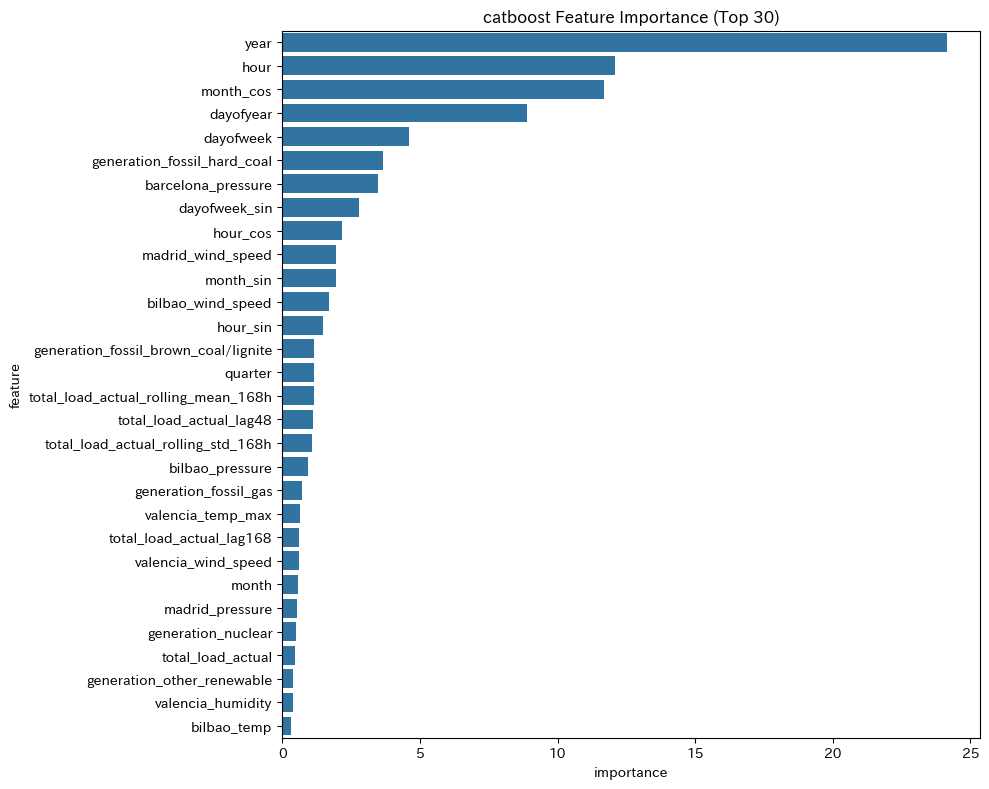


✅ 全工程完了。総所要時間: 105.69 秒
📁 実験結果は以下に保存されました: ./experiment_20250608_224451
[run] 実行完了。所要時間: 105.69 秒


In [4]:
# ===================================================================
# Time Series Prediction Pipeline
# ===================================================================

import os
import warnings
import gc
import time
import json
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Any, Optional
from functools import wraps
from enum import Enum
from datetime import datetime
import pytz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
import holidays

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

# warningsを無視
warnings.filterwarnings("ignore")

# 日本語フォント
import japanize_matplotlib

# Optunaのログ出力を抑制
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 乱数シードの固定
np.random.seed(42)


# ===================================================================
# Enums and Data Classes
# ===================================================================

class ModelType(Enum):
    """サポートするモデルタイプの列挙"""
    LIGHTGBM = "lightgbm"
    XGBOOST = "xgboost"
    CATBOOST = "catboost"
    LINEAR = "linear"


class EnsembleMethod(Enum):
    """アンサンブル手法の列挙"""
    SOFT_VOTING_SIMPLE = "soft_voting_simple"  # 単純平均
    SOFT_VOTING_WEIGHTED = "soft_voting_weighted"  # 重み付き平均
    HARD_VOTING = "hard_voting"  # 多数決（回帰では使用しない）


@dataclass
class ModelConfig:
    """各モデルの設定を管理するデータクラス"""
    model_type: ModelType
    optimize_params: bool = True
    default_params: dict[str, Any] = None
    
    def __post_init__(self):
        """デフォルトパラメータの設定"""
        if self.default_params is None:
            self.default_params = self._get_default_params()
    
    def _get_default_params(self) -> dict[str, Any]:
        """各モデルのデフォルトパラメータを返す"""
        if self.model_type == ModelType.LIGHTGBM:
            return {
                'objective': 'regression_l1',
                'metric': 'rmse',
                'n_estimators': 1000,
                'learning_rate': 0.07482433884957744,
                'feature_fraction': 0.6300023238171889,
                'bagging_fraction': 0.829699153900293,
                'bagging_freq': 53,
                'lambda_l1': 3.394497929235353e-08,
                'lambda_l2': 3.47836637215215e-05,
                'num_leaves': 20,
                'verbose': -1,
                'n_jobs': -1,
                'random_state': 42,
                'boosting_type': 'gbdt',
                'device': 'gpu',  # device_type → device に変更
                'gpu_use_dp': True,  # ダブル精度使用（安定性向上）
                'min_child_samples': 13,
            }
        elif self.model_type == ModelType.XGBOOST:
            return {
                'objective': 'reg:absoluteerror',
                'eval_metric': 'rmse',
                'n_estimators': 614,  # 1000→500に削減（高速化）
                'learning_rate': 0.018870,  # 0.05→0.1に上げて収束を早める
                'subsample': 0.667675,
                'colsample_bytree': 0.616863,
                'reg_alpha': 7.357738,
                'reg_lambda': 0.000006,
                'max_depth': 5,
                'min_child_weight': 6,
                'random_state': 42,
                'n_jobs': -1,
                'verbosity': 0,
                'tree_method': 'gpu_hist',  # GPU使用（利用可能な場合）
                'gpu_id': 0,  # GPU ID指定
                # 'tree_method': 'hist',  # GPU利用不可の場合はこちらを使用
            }
        elif self.model_type == ModelType.CATBOOST:
            return {
                'loss_function': 'RMSE',
                'eval_metric': 'RMSE',
                'iterations': 1000,
                'learning_rate': 0.036406,
                'depth': 6,
                'l2_leaf_reg': 0.000450,
                'bagging_temperature': 0.798822,
                'random_strength': 0.000006,
                'random_seed': 42,
                'verbose': False,  # logging_level → verbose に変更
                'thread_count': -1,
                'task_type': 'GPU',
                'devices': '0',
                'gpu_ram_part': 0.8,  # GPU RAMの使用割合を制限
            }
        elif self.model_type == ModelType.LINEAR:
            return {}
        else:
            raise ValueError(f"Unsupported model type: {self.model_type}")


@dataclass
class Config:
    """実行に関する設定を管理するクラス"""
    DATA_PATH: str = "./rawdata/"
    TARGET_COL: str = "price_actual"
    N_SPLITS: int = 5
    OPTUNA_TRIALS: int = 100
    
    # パラメータ最適化のCV設定
    OPTUNA_CV_FOLDS: Optional[int] = None  # Noneなら全fold、1なら1fold、など
    
    # 実行するモデルの設定
    MODEL_CONFIGS: list[ModelConfig] = None
    
    # アンサンブル設定
    ENABLE_ENSEMBLE: bool = False
    ENSEMBLE_METHOD: EnsembleMethod = EnsembleMethod.SOFT_VOTING_SIMPLE
    ENSEMBLE_WEIGHTS: Optional[list[float]] = None  # 重み付き平均用
    
    # 出力設定
    OUTPUT_PATH: str = "./"
    
    def __post_init__(self):
        """デフォルトのモデル設定"""
        if self.MODEL_CONFIGS is None:
            self.MODEL_CONFIGS = [
                ModelConfig(ModelType.LIGHTGBM, optimize_params=True),
                # ModelConfig(ModelType.XGBOOST, optimize_params=True),
                # ModelConfig(ModelType.CATBOOST, optimize_params=True),
            ]


# ===================================================================
# Utility Functions
# ===================================================================

def log_execution_time(func):
    """関数の実行時間を記録するデコレータ"""
    @wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()
        print(f"[{func.__name__}] 実行開始...")
        result = func(*args, **kwargs)
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"[{func.__name__}] 実行完了。所要時間: {elapsed_time:.2f} 秒")
        return result
    return wrapper


def create_output_directory(base_path: str) -> str:
    """
    日本標準時の情報を含む出力ディレクトリを作成する
    
    Args:
        base_path: ベースパス
        
    Returns:
        作成されたディレクトリのパス
    """
    jst = pytz.timezone('Asia/Tokyo')
    now = datetime.now(jst)
    timestamp = now.strftime("%Y%m%d_%H%M%S")
    
    output_dir = os.path.join(base_path, f"experiment_{timestamp}")
    os.makedirs(output_dir, exist_ok=True)
    
    return output_dir


# ===================================================================
# Feature Engineering
# ===================================================================

class FeatureEngineer:
    """特徴量エンジニアリングを行うクラス"""
    
    @staticmethod
    @log_execution_time
    def create_features(df: pd.DataFrame) -> pd.DataFrame:
        """
        時系列データから特徴量を作成する
        
        Args:
            df: 入力データフレーム
            
        Returns:
            特徴量が追加されたデータフレーム
        """
        df_feat = df.copy()
        
        # スペインの祝日特徴量
        es_holidays = holidays.Spain(years=range(2015, 2019))
        df_feat['is_holiday'] = df_feat.index.normalize().isin(es_holidays).astype(int)

        # 時間特徴量
        df_feat['hour'] = df_feat.index.hour
        df_feat['dayofweek'] = df_feat.index.dayofweek
        df_feat['month'] = df_feat.index.month
        df_feat['year'] = df_feat.index.year
        df_feat['dayofyear'] = df_feat.index.dayofyear
        df_feat['quarter'] = df_feat.index.quarter
        
        # 三角関数による周期特徴量
        df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
        df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)
        df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
        df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
        df_feat['dayofweek_sin'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
        df_feat['dayofweek_cos'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)
        
        # ラグ特徴量 (目的変数はリーク防止のため除外)
        lag_cols = ['total_load_actual', 'generation_solar', 'generation_wind_onshore']
        lags = [24, 48, 168]
        for col in lag_cols:
            for lag in lags:
                df_feat[f'{col}_lag{lag}'] = df_feat[col].shift(lag)

        # 移動統計量 (目的変数はリーク防止のため除外)
        rolling_cols = ['total_load_actual']
        windows = [6, 24, 168]
        for col in rolling_cols:
            for window in windows:
                df_feat[f'{col}_rolling_mean_{window}h'] = df_feat[col].rolling(window=window).mean()
                df_feat[f'{col}_rolling_std_{window}h'] = df_feat[col].rolling(window=window).std()

        # 需要の変化量
        for lag in lags:
            df_feat[f'total_load_actual_diff_{lag}h'] = df_feat['total_load_actual'].diff(lag)

        # 発電比率
        total_load_nonzero = df_feat['total_load_actual'].replace(0, np.nan)
        df_feat['solar_ratio'] = (df_feat['generation_solar'] / total_load_nonzero)
        df_feat['wind_ratio'] = (df_feat['generation_wind_onshore'] / total_load_nonzero)
        
        # 無限大値をNaNに置換
        df_feat.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        gc.collect()
        return df_feat


# ===================================================================
# GPU Utility Functions
# ===================================================================

class GPUChecker:
    """GPU利用可能性をチェックするクラス"""
    
    _gpu_available = None  # クラス変数でキャッシュ
    _gpu_check_done = False
    
    @classmethod
    def is_gpu_available(cls) -> bool:
        """GPU利用可能性をチェック（初回のみ実行）"""
        if cls._gpu_check_done:
            return cls._gpu_available
        
        try:
            import subprocess
            result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
            cls._gpu_available = result.returncode == 0
        except (ImportError, FileNotFoundError):
            cls._gpu_available = False
        
        cls._gpu_check_done = True
        
        if cls._gpu_available:
            print("🚀 GPU利用可能: 全モデルでGPU最適化設定を使用")
        else:
            print("💻 GPU利用不可: 全モデルでCPU最適化設定を使用")
        
        return cls._gpu_available
    
    @classmethod
    def adjust_params_for_gpu(cls, params: dict[str, Any], model_type: ModelType) -> dict[str, Any]:
        """GPU利用可能性に応じてパラメータを調整"""
        gpu_params = params.copy()
        gpu_available = cls.is_gpu_available()
        
        if not gpu_available:
            # GPU利用不可の場合はCPU用設定に変更
            if model_type == ModelType.LIGHTGBM:
                if 'device' in gpu_params:
                    gpu_params['device'] = 'cpu'
                # 古いパラメータ名も削除
                for old_param in ['device_type', 'gpu_platform_id', 'gpu_device_id', 'gpu_use_dp']:
                    if old_param in gpu_params:
                        del gpu_params[old_param]
            
            elif model_type == ModelType.XGBOOST:
                if 'tree_method' in gpu_params and gpu_params['tree_method'] == 'gpu_hist':
                    gpu_params['tree_method'] = 'hist'
                if 'gpu_id' in gpu_params:
                    del gpu_params['gpu_id']
            
            elif model_type == ModelType.CATBOOST:
                if 'task_type' in gpu_params:
                    gpu_params['task_type'] = 'CPU'
                for gpu_param in ['devices', 'gpu_ram_part']:
                    if gpu_param in gpu_params:
                        del gpu_params[gpu_param]
        
        return gpu_params

# ===================================================================
# Base Model Interface
# ===================================================================

class BaseModel(ABC):
    """全てのモデルの基底クラス"""
    
    def __init__(self, config: ModelConfig):
        self.config = config
        self.model = None
        self.is_fitted = False
    
    @abstractmethod
    def create_model(self, params: dict[str, Any]):
        """モデルインスタンスを作成する（各モデルで実装）"""
        pass
    
    @abstractmethod
    def fit_with_validation(self, X_train: pd.DataFrame, y_train: pd.Series, 
                           X_val: pd.DataFrame, y_val: pd.Series):
        """検証データを使ってモデルを学習する（各モデルで実装）"""
        pass
    
    def fit(self, X: pd.DataFrame, y: pd.Series, params: Optional[dict[str, Any]] = None):
        """モデルを学習する"""
        if params is None:
            params = self.config.default_params
        
        self.model = self.create_model(params)
        
        if hasattr(self.model, 'fit'):
            self.model.fit(X, y)
        
        self.is_fitted = True
    
    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """予測を行う"""
        if not self.is_fitted or self.model is None:
            raise ValueError("Model must be fitted before prediction")
        
        return self.model.predict(X)


# ===================================================================
# Concrete Model Implementations
# ===================================================================

class LightGBMModel(BaseModel):
    """LightGBMモデルの実装"""
    
    def create_model(self, params: dict[str, Any]) -> lgb.LGBMRegressor:
        # GPU利用可能性に応じてパラメータを調整
        gpu_params = GPUChecker.adjust_params_for_gpu(params, ModelType.LIGHTGBM)
        model = lgb.LGBMRegressor(**gpu_params)
        return model
    
    def fit_with_validation(self, X_train: pd.DataFrame, y_train: pd.Series, 
                           X_val: pd.DataFrame, y_val: pd.Series):
        self.model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
        )


class XGBoostModel(BaseModel):
    """XGBoostモデルの実装"""
    
    def create_model(self, params: dict[str, Any]) -> xgb.XGBRegressor:
        # GPU利用可能性に応じてパラメータを調整
        gpu_params = GPUChecker.adjust_params_for_gpu(params, ModelType.XGBOOST)
        model = xgb.XGBRegressor(**gpu_params)
        return model
    
    def fit_with_validation(self, X_train: pd.DataFrame, y_train: pd.Series, 
                           X_val: pd.DataFrame, y_val: pd.Series):
        # XGBoostのバージョンによってAPIが異なるため、try-exceptで対応
        try:
            # 新しいAPI (xgboost >= 1.6.0)
            self.model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[xgb.callback.EarlyStopping(rounds=20, save_best=True)],  # 30→20に短縮
                verbose=False
            )
        except TypeError:
            # 古いAPI (xgboost < 1.6.0)
            try:
                self.model.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    early_stopping_rounds=20,  # 30→20に短縮
                    verbose=False
                )
            except TypeError:
                # さらに古いバージョンやその他の問題の場合、eval_setなしで学習
                self.model.fit(X_train, y_train)


class CatBoostModel(BaseModel):
    """CatBoostモデルの実装"""
    
    def create_model(self, params: dict[str, Any]) -> cb.CatBoostRegressor:
        # GPU利用可能性に応じてパラメータを調整
        gpu_params = GPUChecker.adjust_params_for_gpu(params, ModelType.CATBOOST)
        model = cb.CatBoostRegressor(**gpu_params)
        return model
    
    def fit_with_validation(self, X_train: pd.DataFrame, y_train: pd.Series, 
                           X_val: pd.DataFrame, y_val: pd.Series):
        self.model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=20,
            use_best_model=True,
            verbose=False  # fit時のverboseは個別に指定可能
        )


class LinearModel(BaseModel):
    """線形回帰モデルの実装"""
    
    def create_model(self, params: dict[str, Any]) -> LinearRegression:
        return LinearRegression()
    
    def fit_with_validation(self, X_train: pd.DataFrame, y_train: pd.Series, 
                           X_val: pd.DataFrame, y_val: pd.Series):
        # 線形回帰では早期停止は不要
        pass


# ===================================================================
# Model Factory
# ===================================================================

class ModelFactory:
    """モデルファクトリークラス"""
    
    @staticmethod
    def create_model(config: ModelConfig) -> BaseModel:
        """設定に基づいてモデルインスタンスを作成する"""
        if config.model_type == ModelType.LIGHTGBM:
            return LightGBMModel(config)
        elif config.model_type == ModelType.XGBOOST:
            return XGBoostModel(config)
        elif config.model_type == ModelType.CATBOOST:
            return CatBoostModel(config)
        elif config.model_type == ModelType.LINEAR:
            return LinearModel(config)
        else:
            raise ValueError(f"Unsupported model type: {config.model_type}")


# ===================================================================
# Hyperparameter Optimization
# ===================================================================

class HyperparameterOptimizer:
    """ハイパーパラメータ最適化を行うクラス"""
    
    def __init__(self, n_trials: int = 100, n_splits: int = 5, optuna_cv_folds: Optional[int] = None):
        self.n_trials = n_trials
        self.n_splits = n_splits
        self.optuna_cv_folds = optuna_cv_folds  # Optunaで使用するfold数
    
    @log_execution_time
    def optimize(self, model_config: ModelConfig, X: pd.DataFrame, y: pd.Series) -> dict[str, Any]:
        """
        Optunaでハイパーパラメータを最適化する
        
        Args:
            model_config: モデル設定
            X: 特徴量データ
            y: 目的変数データ
            
        Returns:
            最適化されたパラメータ
        """
        def objective(trial: optuna.trial.Trial) -> float:
            params = self._suggest_params(trial, model_config.model_type)
            
            # デフォルトパラメータをベースに更新
            final_params = model_config.default_params.copy()
            final_params.update(params)
            
            # クロスバリデーションで評価
            cv = TimeSeriesSplit(n_splits=self.n_splits)
            scores = []
            
            # OptunaでのCV folds数を制御
            cv_splits = list(cv.split(X))
            if self.optuna_cv_folds is not None:
                # 指定されたfold数のみ使用（最後のfoldから逆順で選択）
                cv_splits = cv_splits[-self.optuna_cv_folds:]
                print(f"    Trial {trial.number + 1}/{self.n_trials}: CV実行中（{self.optuna_cv_folds}/{self.n_splits} folds使用）...")
            else:
                # 全foldを使用
                print(f"    Trial {trial.number + 1}/{self.n_trials}: CV実行中（全{self.n_splits} folds使用）...")
            
            for fold, (train_idx, val_idx) in enumerate(cv_splits):
                fold_start = time.time()
                X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
                X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
                
                model = ModelFactory.create_model(
                    ModelConfig(model_config.model_type, default_params=final_params)
                )
                model.fit(X_train, y_train, final_params)
                
                if hasattr(model, 'fit_with_validation'):
                    model.fit_with_validation(X_train, y_train, X_val, y_val)
                
                val_preds = model.predict(X_val)
                fold_score = root_mean_squared_error(y_val, val_preds)
                scores.append(fold_score)
                
                fold_time = time.time() - fold_start
                # CV folds数に応じて表示を調整
                if self.optuna_cv_folds is not None:
                    # 限定foldの場合、実際のfold番号を表示
                    actual_fold = self.n_splits - self.optuna_cv_folds + fold + 1
                    print(f"      Fold {actual_fold}/{self.n_splits} (使用{fold+1}/{len(cv_splits)}): {fold_score:.4f} ({fold_time:.1f}s)")
                else:
                    # 全foldの場合
                    print(f"      Fold {fold+1}/{len(cv_splits)}: {fold_score:.4f} ({fold_time:.1f}s)")
            
            trial_score = np.mean(scores)
            print(f"    Trial {trial.number + 1} 完了: {trial_score:.4f} (平均)")
            return trial_score
        
        study = optuna.create_study(direction='minimize')
        
        # シンプルなprint表示で最適化実行
        cv_info = f"({self.optuna_cv_folds}/{self.n_splits} folds)" if self.optuna_cv_folds else f"(全{self.n_splits} folds)"
        print(f"  {model_config.model_type.value} 最適化開始 ({self.n_trials} trials, CV{cv_info})")
        
        best_score = float('inf')
        for i in range(self.n_trials):
            trial_start = time.time()
            study.optimize(objective, n_trials=1)
            trial_time = time.time() - trial_start
            
            if study.best_value < best_score:
                best_score = study.best_value
                print(f"  🎯 Trial {i+1}: 新しいベストスコア {best_score:.4f} ({trial_time:.1f}s)")
            else:
                print(f"     Trial {i+1}: {study.trials[-1].value:.4f} ({trial_time:.1f}s)")
        
        print(f"\n✅ {model_config.model_type.value} の最適化完了!")
        print(f"最適化後のベストスコア: {study.best_value:.4f}")
        
        # 最適化されたパラメータの詳細表示
        print(f"\n{model_config.model_type.value} 最適化パラメータ詳細:")
        best_params_display = study.best_params.copy()
        for param, value in best_params_display.items():
            if isinstance(value, float):
                print(f"  {param}: {value:.6f}")
            else:
                print(f"  {param}: {value}")
        
        # 最適パラメータをデフォルトパラメータに統合
        best_params = model_config.default_params.copy()
        best_params.update(study.best_params)
        
        return best_params
    
    def _suggest_params(self, trial: optuna.trial.Trial, model_type: ModelType) -> dict[str, Any]:
        """各モデルタイプに応じたパラメータサジェスト"""
        if model_type == ModelType.LIGHTGBM:
            return {
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
                'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
                'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
                'bagging_freq': trial.suggest_int('bagging_freq', 1, 105), #10
                'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
                'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            }
        elif model_type == ModelType.XGBOOST:
            return {
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
            }
        elif model_type == ModelType.CATBOOST:
            return {
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
                'depth': trial.suggest_int('depth', 3, 10),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
                'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
                'random_strength': trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
            }
        else:
            return {}


# ===================================================================
# Ensemble Methods
# ===================================================================

class EnsemblePredictor:
    """アンサンブル予測を行うクラス"""
    
    def __init__(self, method: EnsembleMethod, weights: Optional[list[float]] = None):
        self.method = method
        self.weights = weights
    
    def predict(self, predictions: list[np.ndarray]) -> np.ndarray:
        """
        複数の予測結果をアンサンブルする
        
        Args:
            predictions: 各モデルの予測結果のリスト
            
        Returns:
            アンサンブル後の予測結果
        """
        if len(predictions) == 1:
            return predictions[0]
        
        predictions_array = np.array(predictions)
        
        if self.method == EnsembleMethod.SOFT_VOTING_SIMPLE:
            return np.mean(predictions_array, axis=0)
        
        elif self.method == EnsembleMethod.SOFT_VOTING_WEIGHTED:
            if self.weights is None:
                raise ValueError("Weights must be provided for weighted ensemble")
            if len(self.weights) != len(predictions):
                raise ValueError("Number of weights must match number of predictions")
            
            weights_array = np.array(self.weights)
            weights_array = weights_array / np.sum(weights_array)  # 正規化
            
            return np.average(predictions_array, axis=0, weights=weights_array)
        
        else:
            raise ValueError(f"Unsupported ensemble method: {self.method}")


# ===================================================================
# Model Pipeline
# ===================================================================

class ModelPipeline:
    """モデル学習・評価のパイプライン"""
    
    def __init__(self, config: Config):
        self.config = config
        self.models: dict[str, BaseModel] = {}
        self.model_scores: dict[str, float] = {}
        self.final_params: dict[str, dict[str, Any]] = {}  # 最終パラメータを保存
        # 修正: optuna_cv_foldsパラメータを正しく渡す
        self.optimizer = HyperparameterOptimizer(
            n_trials=config.OPTUNA_TRIALS,
            n_splits=config.N_SPLITS,
            optuna_cv_folds=config.OPTUNA_CV_FOLDS  # この行を追加
        )
    
    @log_execution_time
    def train_and_evaluate(self, X_train: pd.DataFrame, y_train: pd.Series) -> dict[str, float]:
        """
        全てのモデルを学習・評価する
        
        Args:
            X_train: 学習用特徴量
            y_train: 学習用目的変数
            
        Returns:
            各モデルのCVスコア
        """
        results = {}
        
        # 1. 最初に線形回帰をベースライン指標として実行
        print(f"\n{'='*50}")
        print("ベースライン指標: Linear Regression の評価")
        print(f"{'='*50}")
        
        lr_config = ModelConfig(ModelType.LINEAR, optimize_params=False)
        
        # ベースライン評価：最適化設定があっても常に全foldで評価（一貫性のため）
        print(f"ベースライン評価は常に全{self.config.N_SPLITS}foldsで実行します（一貫性のため）")
        lr_score = self._cross_validate(lr_config, X_train, y_train, use_optuna_folds=False)
        results['Linear Regression (Baseline)'] = lr_score
        
        lr_model = ModelFactory.create_model(lr_config)
        lr_model.fit(X_train, y_train, lr_config.default_params)
        self.models['linear_baseline'] = lr_model
        self.final_params['linear_baseline'] = lr_config.default_params
        
        print(f"  -> ベースライン CV Score: {lr_score:.4f} (全{self.config.N_SPLITS} folds使用)")
        print(f"     (この値を上回ることが目標です)")
        
        # 2. 設定されたモデルを順次実行
        total_models = len(self.config.MODEL_CONFIGS)
        for idx, model_config in enumerate(self.config.MODEL_CONFIGS, 1):
            model_name = model_config.model_type.value
            print(f"\n{'='*50}")
            print(f"[{idx}/{total_models}] {model_name} の学習・評価を開始")
            print(f"{'='*50}")
            
            model_start_time = time.time()
            
            # ハイパーパラメータ最適化
            if model_config.optimize_params and model_config.model_type != ModelType.LINEAR:
                print(f"{model_name} のハイパーパラメータ最適化中...")
                optimize_start = time.time()
                optimized_params = self.optimizer.optimize(model_config, X_train, y_train)
                optimize_time = time.time() - optimize_start
                print(f"  最適化完了 ({optimize_time:.1f}s)")
                
                # 最適化されたパラメータを表示
                print(f"\n{model_name} 最適化パラメータ:")
                optimized_only = {k: v for k, v in optimized_params.items() 
                                if k not in model_config._get_default_params() or 
                                   optimized_params[k] != model_config._get_default_params()[k]}
                for param, value in optimized_only.items():
                    if isinstance(value, float):
                        print(f"  {param}: {value:.6f}")
                    else:
                        print(f"  {param}: {value}")
                
                model_config.default_params = optimized_params
            else:
                print(f"{model_name} はパラメータ最適化をスキップします")
            
            # 最終パラメータを保存
            self.final_params[model_name] = model_config.default_params
            
            # クロスバリデーション評価
            print(f"\n{model_name} 最終CV評価中...")
            cv_start = time.time()
            cv_score = self._cross_validate(model_config, X_train, y_train, use_optuna_folds=False)  # 最終評価は全foldで実行
            cv_time = time.time() - cv_start
            print(f"  CV評価完了 ({cv_time:.1f}s)")
            
            results[model_name] = cv_score
            self.model_scores[model_name] = cv_score
            
            # ベースラインとの比較表示
            improvement = lr_score - cv_score
            improvement_pct = (improvement / lr_score) * 100
            if improvement > 0:
                print(f"  -> CV Score: {cv_score:.4f} (ベースラインより {improvement:.4f} 改善, {improvement_pct:.1f}%向上)")
            else:
                print(f"  -> CV Score: {cv_score:.4f} (ベースラインより {abs(improvement):.4f} 悪化)")
            
            # 最終モデルの学習
            print(f"\n{model_name} 最終モデル学習中...")
            final_train_start = time.time()
            model = ModelFactory.create_model(model_config)
            model.fit(X_train, y_train, model_config.default_params)
            self.models[model_name] = model
            final_train_time = time.time() - final_train_start
            
            model_total_time = time.time() - model_start_time
            print(f"  最終モデル学習完了 ({final_train_time:.1f}s)")
            print(f"  {model_name} 全体処理時間: {model_total_time:.1f}s")
        
        return results
    
    def _cross_validate(self, model_config: ModelConfig, X: pd.DataFrame, y: pd.Series, 
                       use_optuna_folds: bool = False) -> float:
        """
        クロスバリデーションを実行する
        
        Args:
            model_config: モデル設定
            X: 特徴量データ
            y: 目的変数データ
            use_optuna_folds: OPTUNA_CV_FOLDS設定を使用するかどうか
        
        Returns:
            CVスコア（RMSE）
        """
        cv = TimeSeriesSplit(n_splits=self.config.N_SPLITS)
        scores = []
        
        # CV folds数を決定
        cv_splits = list(cv.split(X))
        if use_optuna_folds and self.config.OPTUNA_CV_FOLDS is not None:
            # OPTUNA_CV_FOLDS設定を使用（最後のfoldから逆順で選択）
            cv_splits = cv_splits[-self.config.OPTUNA_CV_FOLDS:]
            cv_info = f"({self.config.OPTUNA_CV_FOLDS}/{self.config.N_SPLITS} folds)"
        else:
            # 全foldを使用
            cv_info = f"({len(cv_splits)} folds)"
        
        print(f"  CV開始 {cv_info}")
        
        for fold, (train_idx, val_idx) in enumerate(cv_splits):
            fold_start = time.time()
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
            
            model = ModelFactory.create_model(model_config)
            model.fit(X_train, y_train, model_config.default_params)
            
            if hasattr(model, 'fit_with_validation'):
                model.fit_with_validation(X_train, y_train, X_val, y_val)
            
            val_preds = model.predict(X_val)
            fold_score = root_mean_squared_error(y_val, val_preds)
            scores.append(fold_score)
            
            fold_time = time.time() - fold_start
            
            # fold表示を調整
            if use_optuna_folds and self.config.OPTUNA_CV_FOLDS is not None:
                # 限定foldの場合、実際のfold番号を表示
                actual_fold = self.config.N_SPLITS - self.config.OPTUNA_CV_FOLDS + fold + 1
                print(f"    Fold {actual_fold}/{self.config.N_SPLITS} (使用{fold+1}/{len(cv_splits)}): {fold_score:.4f} ({fold_time:.1f}s)")
            else:
                # 全foldの場合
                print(f"    Fold {fold+1}/{len(cv_splits)}: {fold_score:.4f} ({fold_time:.1f}s)")
        
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        print(f"  CV結果: {mean_score:.4f} ± {std_score:.4f}")
        
        return mean_score
    
    def predict(self, X_test: pd.DataFrame) -> dict[str, np.ndarray]:
        """各モデルで予測を実行する（ベースラインモデルは除外）"""
        predictions = {}
        
        # ベースラインモデルを除外してアンサンブル対象モデルのみ予測
        excluded_models = {'linear_baseline'}
        
        for model_name, model in self.models.items():
            if model_name not in excluded_models:
                predictions[model_name] = model.predict(X_test)
        
        return predictions
    
    def predict_all_models(self, X_test: pd.DataFrame) -> dict[str, np.ndarray]:
        """全てのモデル（ベースライン含む）で予測を実行する"""
        predictions = {}
        
        for model_name, model in self.models.items():
            predictions[model_name] = model.predict(X_test)
        
        return predictions
    
    def create_ensemble_prediction(self, predictions: dict[str, np.ndarray]) -> np.ndarray:
        """アンサンブル予測を作成する"""
        if not self.config.ENABLE_ENSEMBLE or len(predictions) <= 1:
            # アンサンブルが無効またはモデルが1つの場合は最初のモデルの予測を返す
            return list(predictions.values())[0]
        
        ensemble_predictor = EnsemblePredictor(
            method=self.config.ENSEMBLE_METHOD,
            weights=self.config.ENSEMBLE_WEIGHTS
        )
        
        return ensemble_predictor.predict(list(predictions.values()))


# ===================================================================
# Visualization
# ===================================================================

class Visualizer:
    """可視化を行うクラス"""
    
    @staticmethod
    def plot_feature_importance(model: BaseModel, feature_names: list[str], model_name: str):
        """Feature Importanceをプロットする"""
        if not hasattr(model.model, 'feature_importances_'):
            print(f"  -> {model_name}はFeature Importanceをサポートしていません")
            return
        
        importances = pd.DataFrame({
            'feature': feature_names,
            'importance': model.model.feature_importances_
        }).sort_values('importance', ascending=False).head(30)
        
        plt.figure(figsize=(10, 8))
        sns.barplot(x='importance', y='feature', data=importances)
        plt.title(f'{model_name} Feature Importance (Top 30)')
        plt.tight_layout()
        plt.show()
    
    @staticmethod
    def plot_predictions_distribution(predictions: dict[str, pd.Series], y_train: pd.Series):
        """予測値の分布を可視化する"""
        n_models = len(predictions)
        fig, axes = plt.subplots(n_models + 1, 1, figsize=(18, 6 * (n_models + 1)))
        
        if n_models == 1:
            axes = [axes]
        
        # 各モデルの予測値の時系列プロット
        for i, (model_name, pred_series) in enumerate(predictions.items()):
            pred_series.plot(ax=axes[i], label=f'{model_name} Predictions', color=f'C{i}')
            axes[i].set_title(f'{model_name} Predictions Over Time')
            axes[i].set_ylabel('Predicted Price')
            axes[i].legend()
            axes[i].grid(True)
        
        # 分布の比較
        ax_dist = axes[-1]
        sns.histplot(y_train, ax=ax_dist, color='blue', label='Train Actual Price', 
                    kde=True, stat='density', alpha=0.6)
        
        for i, (model_name, pred_series) in enumerate(predictions.items()):
            sns.histplot(pred_series, ax=ax_dist, color=f'C{i}', label=f'{model_name} Predictions', 
                        kde=True, stat='density', alpha=0.6)
        
        ax_dist.set_title('Distribution Comparison: Train Actual vs. Model Predictions')
        ax_dist.legend()
        ax_dist.grid(True)
        
        plt.tight_layout()
        plt.show()


# ===================================================================
# Output Manager
# ===================================================================

class OutputManager:
    """実行結果の出力を管理するクラス"""
    
    def __init__(self, output_dir: str):
        self.output_dir = output_dir
    
    def save_submission_files(self, predictions: dict[str, np.ndarray], 
                            sample_submission_path: str):
        """
        各モデルの提出ファイルを保存する
        
        Args:
            predictions: 各モデルの予測結果
            sample_submission_path: サンプル提出ファイルのパス
        """
        sample_submission_df = pd.read_csv(sample_submission_path, header=None)
        
        # シンプルなprint表示で提出ファイル作成
        total_files = len(predictions)
        print(f"\n提出ファイル作成中 ({total_files} files)...")
        
        for idx, (model_name, pred) in enumerate(predictions.items(), 1):
            file_start = time.time()
            
            submission_df = sample_submission_df.copy()
            submission_df[1] = pred
            
            filename = os.path.join(self.output_dir, f'submission_{model_name}.csv')
            submission_df.to_csv(filename, header=False, index=False)
            
            file_time = time.time() - file_start
            print(f"  [{idx}/{total_files}] submission_{model_name}.csv 作成完了 ({file_time:.2f}s)")
            
            # デバッグ情報
            print(f"    {model_name} 予測値統計:")
            print(f"      平均: {pred.mean():.2f}, 標準偏差: {pred.std():.2f}")
            print(f"      最小値: {pred.min():.2f}, 最大値: {pred.max():.2f}")
        
        print("✅ 全ての提出ファイルが作成されました。")
    
    def save_model_parameters(self, final_params: dict[str, dict[str, Any]], 
                            cv_results: dict[str, float]):
        """
        最終的な学習パラメータと結果をJSONファイルに保存する
        
        Args:
            final_params: 各モデルの最終パラメータ
            cv_results: CVスコア結果
        """
        # 日本標準時の情報を追加
        jst = pytz.timezone('Asia/Tokyo')
        now = datetime.now(jst)
        
        output_data = {
            "experiment_info": {
                "timestamp": now.isoformat(),
                "execution_date": now.strftime("%Y年%m月%d日 %H時%M分%S秒"),
                "timezone": "Asia/Tokyo"
            },
            "cv_results": cv_results,
            "model_parameters": {}
        }
        
        # 各モデルのパラメータを保存（JSON serializable な形に変換）
        for model_name, params in final_params.items():
            serializable_params = {}
            for key, value in params.items():
                if isinstance(value, (int, float, str, bool, type(None))):
                    serializable_params[key] = value
                elif isinstance(value, np.integer):
                    serializable_params[key] = int(value)
                elif isinstance(value, np.floating):
                    serializable_params[key] = float(value)
                else:
                    serializable_params[key] = str(value)
            
            output_data["model_parameters"][model_name] = serializable_params
        
        # JSONファイルに保存
        filename = os.path.join(self.output_dir, 'experiment_parameters.json')
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(output_data, f, indent=2, ensure_ascii=False)
        
        print(f"\n📄 実験パラメータを保存しました: experiment_parameters.json")
        print(f"   実行日時: {output_data['experiment_info']['execution_date']}")


# ===================================================================
# Main Execution Class
# ===================================================================

class CompetitionPipeline:
    """コンペティション用のメインパイプライン"""
    
    def __init__(self, config: Config):
        self.config = config
        self.feature_engineer = FeatureEngineer()
        self.pipeline = ModelPipeline(config)
        self.visualizer = Visualizer()
        
        # 出力ディレクトリを作成
        self.output_dir = create_output_directory(config.OUTPUT_PATH)
        self.output_manager = OutputManager(self.output_dir)
    
    @log_execution_time
    def run(self):
        """メイン実行処理"""
        start_all = time.time()
        
        print(f"📁 実験結果出力先: {self.output_dir}")
        
        # GPU利用可能性チェック（初回のみ）
        GPUChecker.is_gpu_available()
        
        # データ読み込み
        print("\nデータの読み込み中...")
        train_df, test_df = self._load_data()
        
        # 特徴量作成
        X_train, y_train, X_test, feature_cols = self._prepare_features(train_df, test_df)
        
        # モデル学習・評価
        print("\n" + "="*50)
        print("モデル学習・評価フェーズ")
        print("="*50)
        
        cv_results = self.pipeline.train_and_evaluate(X_train, y_train)
        
        # 結果表示
        self._display_results(cv_results)
        
        # 予測実行
        print("\n" + "="*50)
        print("予測・提出ファイル作成フェーズ")
        print("="*50)
        
        # 全モデルの予測（提出ファイル作成用）
        all_predictions = self.pipeline.predict_all_models(X_test)
        
        # アンサンブル対象モデルのみの予測
        ensemble_predictions = self.pipeline.predict(X_test)
        
        # 個別モデルの提出ファイル作成（全モデル）
        sample_submission_path = os.path.join(self.config.DATA_PATH, 'sample_submit.csv')
        self.output_manager.save_submission_files(all_predictions, sample_submission_path)
        
        # アンサンブル予測の判定と実行
        eligible_models = list(ensemble_predictions.keys())
        print(f"\nアンサンブル対象モデル: {eligible_models}")
        
        if self.config.ENABLE_ENSEMBLE and len(ensemble_predictions) > 1:
            ensemble_pred = self.pipeline.create_ensemble_prediction(ensemble_predictions)
            ensemble_pred_series = pd.Series(ensemble_pred, index=test_df.index)
            
            print(f"アンサンブル予測を作成しました ({self.config.ENSEMBLE_METHOD.value})")
            print(f"使用モデル: {', '.join(eligible_models)}")
            
            # アンサンブル予測ファイルを保存
            ensemble_predictions_dict = {"ensemble": ensemble_pred}
            self.output_manager.save_submission_files(ensemble_predictions_dict, sample_submission_path)
            
            # アンサンブル結果も可視化に含める
            all_predictions["ensemble"] = ensemble_pred_series
        elif self.config.ENABLE_ENSEMBLE and len(ensemble_predictions) == 1:
            print(f"⚠️  アンサンブル実行不可: アンサンブル対象モデルが1つのみです")
            print(f"   対象モデル: {eligible_models[0]}")
            print(f"   (Linear Regressionはベースラインのためアンサンブルに含まれません)")
        elif self.config.ENABLE_ENSEMBLE:
            print(f"⚠️  アンサンブル実行不可: アンサンブル対象モデルがありません")
        else:
            print(f"ℹ️  アンサンブル無効: 設定でアンサンブルが無効化されています")
        
        # 最終パラメータとCV結果を保存
        self.output_manager.save_model_parameters(self.pipeline.final_params, cv_results)
        
        # 可視化（全モデルを含む）
        print("\n予測結果の可視化...")
        pred_series = {name: pd.Series(pred, index=test_df.index) 
                      for name, pred in all_predictions.items()}
        self.visualizer.plot_predictions_distribution(pred_series, y_train)
        
        # Feature Importance可視化（ベースラインは除外）
        excluded_models = {'linear_baseline'}
        for model_name, model in self.pipeline.models.items():
            if model_name not in excluded_models:
                self.visualizer.plot_feature_importance(model, feature_cols, model_name)
        
        total_time = time.time() - start_all
        print(f"\n✅ 全工程完了。総所要時間: {total_time:.2f} 秒")
        print(f"📁 実験結果は以下に保存されました: {self.output_dir}")
    
    def _load_data(self) -> tuple[pd.DataFrame, pd.DataFrame]:
        """データを読み込む"""
        train_df = pd.read_csv(self.config.DATA_PATH + 'train.csv', index_col=0)
        test_df = pd.read_csv(self.config.DATA_PATH + 'test.csv', index_col=0)
        
        train_df.index = pd.to_datetime(train_df.index, utc=True).tz_convert('Europe/Madrid')
        test_df.index = pd.to_datetime(test_df.index, utc=True).tz_convert('Europe/Madrid')
        
        return train_df, test_df
    
    def _prepare_features(self, train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, list[str]]:
        """特徴量を準備する"""
        df_all = pd.concat([train_df, test_df], axis=0)
        df_all_feat = self.feature_engineer.create_features(df_all)
        
        # カテゴリカル特徴量のOne-Hotエンコーディング
        categorical_cols = df_all_feat.select_dtypes(include=['object']).columns
        if not categorical_cols.empty:
            print(f"カテゴリカル特徴量をOne-Hotエンコーディングします: {list(categorical_cols)}")
            df_all_feat = pd.get_dummies(df_all_feat, columns=categorical_cols, dummy_na=False)
        
        # 欠損値処理
        df_all_feat.fillna(method='ffill', inplace=True)
        df_all_feat.fillna(0, inplace=True)
        
        # 学習・テストデータの分割
        train_feat_df = df_all_feat.loc[train_df.index].copy()
        test_feat_df = df_all_feat.loc[test_df.index].copy()
        
        feature_cols = [col for col in train_feat_df.columns if col != self.config.TARGET_COL]
        
        X_train = train_feat_df[feature_cols]
        y_train = train_feat_df[self.config.TARGET_COL]
        X_test = test_feat_df[feature_cols]
        
        # モデル間で特徴量の列順を一致させる
        X_test = X_test[X_train.columns]
        
        print(f"\n使用する特徴量数: {len(feature_cols)}")
        print(f"訓練データの欠損値数: {X_train.isna().sum().sum()}")
        print(f"テストデータの欠損値数: {X_test.isna().sum().sum()}")
        
        return X_train, y_train, X_test, feature_cols
    
    def _display_results(self, cv_results: dict[str, float]):
        """CV結果を表示する"""
        print("\n" + "="*50)
        print("CVスコア サマリー (RMSE)")
        print("="*50)
        
        # ベースラインを最初に表示
        baseline_key = "Linear Regression (Baseline)"
        if baseline_key in cv_results:
            print(f"  📊 {baseline_key:<25}: {cv_results[baseline_key]:.4f}")
            print("  " + "-"*48)
        
        # 他のモデルをスコア順で表示（ベースラインは除外）
        excluded_models = {baseline_key}
        other_results = {k: v for k, v in cv_results.items() if k not in excluded_models}
        sorted_results = sorted(other_results.items(), key=lambda x: x[1])
        
        for i, (model_name, score) in enumerate(sorted_results):
            if i == 0:
                emoji = "🥇"  # 1位
            elif i == 1:
                emoji = "🥈"  # 2位
            elif i == 2:
                emoji = "🥉"  # 3位
            else:
                emoji = "  "
            
            # ベースラインとの比較
            if baseline_key in cv_results:
                improvement = cv_results[baseline_key] - score
                if improvement > 0:
                    improvement_str = f"(+{improvement:.4f})"
                else:
                    improvement_str = f"({improvement:.4f})"
                print(f"  {emoji} {model_name:<25}: {score:.4f} {improvement_str}")
            else:
                print(f"  {emoji} {model_name:<25}: {score:.4f}")
        
        print("="*50)
        
        # アンサンブル対象モデルの明記（ベースライン除外）
        excluded_models = {baseline_key}
        other_results = {k: v for k, v in cv_results.items() if k not in excluded_models}
        
        if len(other_results) > 1:
            ensemble_models = ", ".join(other_results.keys())
            print(f"📦 アンサンブル対象: {ensemble_models}")
            print(f"   (Linear Regressionはベースラインのためアンサンブルから除外)")
        elif len(other_results) == 1:
            single_model = list(other_results.keys())[0]
            print(f"⚠️  アンサンブル実行不可: アンサンブル対象モデルが1つのみ ({single_model})")
            print(f"   (Linear Regressionはベースラインのためアンサンブルから除外)")
        else:
            print("⚠️  アンサンブル実行不可: アンサンブル対象モデルがありません")


# ===================================================================
# Configuration Examples
# ===================================================================

def create_single_model_config() -> Config:
    """単一モデル実行用の設定例"""
    return Config(
        MODEL_CONFIGS=[
            ModelConfig(ModelType.LIGHTGBM, optimize_params=True),
        ],
        ENABLE_ENSEMBLE=False
    )


def create_multi_model_config() -> Config:
    """複数モデル実行用の設定例"""
    return Config(
        MODEL_CONFIGS=[
            ModelConfig(ModelType.LIGHTGBM, optimize_params=True),
            ModelConfig(ModelType.XGBOOST, optimize_params=True),
            ModelConfig(ModelType.CATBOOST, optimize_params=False),  # 最適化なし
        ],
        ENABLE_ENSEMBLE=True,
        ENSEMBLE_METHOD=EnsembleMethod.SOFT_VOTING_SIMPLE
    )


def create_weighted_ensemble_config() -> Config:
    """重み付きアンサンブル用の設定例"""
    return Config(
        MODEL_CONFIGS=[
            ModelConfig(ModelType.LIGHTGBM, optimize_params=True),
            ModelConfig(ModelType.XGBOOST, optimize_params=True),
            ModelConfig(ModelType.CATBOOST, optimize_params=True),
        ],
        ENABLE_ENSEMBLE=True,
        ENSEMBLE_METHOD=EnsembleMethod.SOFT_VOTING_WEIGHTED,
        ENSEMBLE_WEIGHTS=[0.5, 0.3, 0.2]  # LightGBM:50%, XGBoost:30%, CatBoost:20%
    )


def create_gpu_optimized_config() -> Config:
    """GPU最適化設定例"""
    return Config(
        MODEL_CONFIGS=[
            ModelConfig(ModelType.LIGHTGBM, optimize_params=True),
            ModelConfig(ModelType.XGBOOST, optimize_params=True),  # GPU設定済み
        ],
        ENABLE_ENSEMBLE=True,
        ENSEMBLE_METHOD=EnsembleMethod.SOFT_VOTING_SIMPLE,
        OPTUNA_TRIALS=30,
        OPTUNA_CV_FOLDS=None  # 全foldを使用
    )


def create_fast_optimization_config() -> Config:
    """高速最適化設定例（1fold CVでパラメータ最適化）"""
    return Config(
        MODEL_CONFIGS=[
            ModelConfig(ModelType.LIGHTGBM, optimize_params=False),
            ModelConfig(ModelType.XGBOOST, optimize_params=False),
            ModelConfig(ModelType.CATBOOST, optimize_params=False),
        ],
        ENABLE_ENSEMBLE=True,
        ENSEMBLE_METHOD=EnsembleMethod.SOFT_VOTING_SIMPLE,
        OPTUNA_TRIALS=150,  # トライアル数を削減
        OPTUNA_CV_FOLDS=2  # 最適化時は1foldのみ（高速化）
    )


# ===================================================================
# Example Usage
# ===================================================================

def main():
    """メイン実行関数の例"""
    
    # 設定例1: 単一モデル（LightGBM）のみ実行
    # config = create_single_model_config()
    
    # 設定例2: 複数モデル実行 + 単純平均アンサンブル
    # config = create_multi_model_config()
    
    # 設定例3: 重み付きアンサンブル
    # config = create_weighted_ensemble_config()
    
    # 設定例4: GPU最適化（推奨、全fold CV）
    # config = create_gpu_optimized_config()
    
    # 設定例5: 高速最適化（3fold CVでパラメータ最適化）
    config = create_fast_optimization_config()
    
    # カスタム設定例: 高速実行
    # config = Config(
    #     MODEL_CONFIGS=[
    #         ModelConfig(ModelType.LIGHTGBM, optimize_params=False),
    #         ModelConfig(ModelType.XGBOOST, optimize_params=False),
    #     ],
    #     ENABLE_ENSEMBLE=True,
    #     ENSEMBLE_METHOD=EnsembleMethod.SOFT_VOTING_SIMPLE,
    #     OPTUNA_TRIALS=10,  # 最適化する場合のトライアル数を大幅削減
    #     OPTUNA_CV_FOLDS=1  # 最適化時は1foldのみ
    # )
    
    # パイプライン実行
    pipeline = CompetitionPipeline(config)
    pipeline.run()


if __name__ == '__main__':
    main()

In [ ]:
==================================================
CVスコア サマリー (RMSE)
==================================================
  📊 Linear Regression (Baseline): 15.9114
  ------------------------------------------------
  🥇 catboost                 : 11.4864 (+4.4250)
  🥈 xgboost                  : 11.7126 (+4.1987)
  🥉 lightgbm                 : 11.9145 (+3.9969)
==================================================
📦 アンサンブル対象: lightgbm, xgboost, catboost
   (Linear Regressionはベースラインのためアンサンブルから除外)

In [ ]:
lightgbm 全体処理時間: 1423.3s
catboost 全体処理時間: 2616.6s
[train_and_evaluate] 実行完了。所要時間: 7944.19 秒
xgboost 最適化パラメータ詳細:
  learning_rate: 0.013970
  subsample: 0.640624
  colsample_bytree: 0.610147
  reg_alpha: 0.000000
  reg_lambda: 0.000010
  max_depth: 9
  min_child_weight: 1
  n_estimators: 200
[optimize] 実行完了。所要時間: 3857.10 秒
  最適化完了 (3857.1s)

xgboost 最適化パラメータ:
  n_estimators: 200
  learning_rate: 0.013970
  subsample: 0.640624
  colsample_bytree: 0.610147
  reg_alpha: 0.000000
  reg_lambda: 0.000010
  max_depth: 9
  min_child_weight: 1

xgboost 最終CV評価中...
  CV開始 (5 folds)
  💻 XGBoost: CPU設定で実行
    Fold 1/5: 8.0204 (5.6s)
  💻 XGBoost: CPU設定で実行
    Fold 2/5: 21.5861 (7.0s)
  💻 XGBoost: CPU設定で実行
    Fold 3/5: 12.1100 (8.2s)
  💻 XGBoost: CPU設定で実行
    Fold 4/5: 18.4019 (9.4s)
  💻 XGBoost: CPU設定で実行
    Fold 5/5: 6.6695 (10.0s)
  CV結果: 13.3576 ± 5.7953
  CV評価完了 (40.2s)
  -> CV Score: 13.3576 (ベースラインより 2.5538 改善, 16.1%向上)

xgboost 最終モデル学習中...
  💻 XGBoost: CPU設定で実行
  最終モデル学習完了 (5.3s)
  xgboost 全体処理時間: 3902.6s
    
    
==================================================
CVスコア サマリー (RMSE)
==================================================
  📊 Linear Regression (Baseline): 15.9114
  ------------------------------------------------
  🥇 catboost                 : 11.4341 (+4.4772)
  🥈 lightgbm                 : 11.8140 (+4.0974)
  🥉 xgboost                  : 13.3576 (+2.5538)
==================================================
📦 アンサンブル対象: lightgbm, xgboost, catboost

全工程完了。総所要時間: 7948.82 秒
[run] 実行完了。所要時間: 7948.82 秒

In [ ]:
✅ xgboost の最適化完了!
最適化後のベストスコア: 12.3265

xgboost 最適化パラメータ詳細:
  learning_rate: 0.018870
  subsample: 0.667675
  colsample_bytree: 0.616863
  reg_alpha: 7.357738
  reg_lambda: 0.000006
  max_depth: 5
  min_child_weight: 6
  n_estimators: 614　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　
[optimize] 実行完了。所要時間: 24080.45 秒
  最適化完了 (24080.5s)

xgboost 最適化パラメータ:
  n_estimators: 614
  learning_rate: 0.018870
  subsample: 0.667675
  colsample_bytree: 0.616863
  reg_alpha: 7.357738
  reg_lambda: 0.000006
  max_depth: 5
  min_child_weight: 6

xgboost 最終CV評価中...
  CV開始 (5 folds)
    Fold 1/5: 7.7567 (4.8s)
    Fold 2/5: 20.3620 (5.5s)
    Fold 3/5: 11.7917 (9.1s)
    Fold 4/5: 19.3011 (6.7s)
    Fold 5/5: 5.8867 (7.0s)
  CV結果: 13.0197 ± 5.8899
  CV評価完了 (33.1s)
  -> CV Score: 13.0197 (ベースラインより 2.8917 改善, 18.2%向上)

xgboost 最終モデル学習中...
  最終モデル学習完了 (3.8s)
  xgboost 全体処理時間: 24117.4s

In [ ]:
✅ catboost の最適化完了!
最適化後のベストスコア: 9.9931

catboost 最適化パラメータ詳細:
  learning_rate: 0.036406
  depth: 6
  l2_leaf_reg: 0.000450
  bagging_temperature: 0.798822
  random_strength: 0.000006
[optimize] 実行完了。所要時間: 2445.58 秒
  最適化完了 (2445.6s)

catboost 最適化パラメータ:
  learning_rate: 0.036406
  l2_leaf_reg: 0.000450
  bagging_temperature: 0.798822
  random_strength: 0.000006

catboost 最終CV評価中...
  CV開始 (5 folds)
    Fold 1/5: 8.2006 (4.4s)
    Fold 2/5: 18.0024 (6.1s)
    Fold 3/5: 11.1188 (5.2s)
    Fold 4/5: 14.3248 (6.2s)
    Fold 5/5: 5.6613 (10.6s)
  CV結果: 11.4616 ± 4.3675
  CV評価完了 (32.3s)
  -> CV Score: 11.4616 (ベースラインより 4.4498 改善, 28.0%向上)

catboost 最終モデル学習中...
  最終モデル学習完了 (5.7s)
  catboost 全体処理時間: 2483.6s
[train_and_evaluate] 実行完了。所要時間: 2545.68 秒

==================================================
CVスコア サマリー (RMSE)
==================================================
  📊 Linear Regression (Baseline): 15.9114
  ------------------------------------------------
  🥇 lightgbm                 : 9.9604 (+5.9509)
  🥈 catboost                 : 11.4616 (+4.4498)
  🥉 xgboost                  : 12.9964 (+2.9150)
==================================================
📦 アンサンブル対象: lightgbm, xgboost, catboost
   (Linear Regressionはベースラインのためアンサンブルから除外)

==================================================
予測・提出ファイル作成フェーズ
==================================================

提出ファイル作成中 (4 files)...
  [1/4] submission_linear_baseline.csv 作成完了 (0.02s)
    linear_baseline 予測値統計:
      平均: 55.29, 標準偏差: 9.77
      最小値: 17.43, 最大値: 96.83
  [2/4] submission_lightgbm.csv 作成完了 (0.02s)
    lightgbm 予測値統計:
      平均: 57.40, 標準偏差: 10.72
      最小値: 23.15, 最大値: 95.80
  [3/4] submission_xgboost.csv 作成完了 (0.02s)
    xgboost 予測値統計:
      平均: 57.35, 標準偏差: 9.57
      最小値: 26.33, 最大値: 90.57
  [4/4] submission_catboost.csv 作成完了 (0.02s)
    catboost 予測値統計:
      平均: 57.47, 標準偏差: 10.40
      最小値: 26.26, 最大値: 95.38
✅ 全ての提出ファイルが作成されました。